In [1]:
import pandas as pd
df = pd.read_csv("credit_card_details.csv")
df.head(10)  

,index,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,1,01-01-2019 00:00,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149.0,NaN,21-06-1978,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0.0
1,2,01-01-2019 00:00,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154.0,Nature conservation officer,19-01-1962,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0.0
2,3,01-01-2019 00:07,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589.0,Systems analyst,21-12-1945,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0.0
3,4,01-01-2019 00:09,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899.0,Naval architect,30-08-1967,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0.0
4,5,01-01-2019 00:21,Bruen-Yost,misc_pos,6.85,Freedom,WY,NaN,-111.0292,471.0,"Education officer, museum",02-08-1967,NaN,43.753735,-111.454923,0.0
5,6,01-01-2019 00:22,Kunze Inc,grocery_pos,90.22,Honokaa,NaN,NaN,-155.4880,4878.0,Physiotherapist,03-12-1966,95826e3caa9e0b905294c6dae985aec1,19.560013,-156.045889,0.0
6,7,01-01-2019 00:22,NaN,shopping_pos,4.02,Valentine,NE,42.8062,-100.6215,4005.0,Network engineer,15-03-1945,20490f3f0966ce74b4aaba8dc2c4ed52,42.475590,-101.265846,0.0
7,8,01-01-2019 00:22,"Kihn, Abernathy and Douglas",shopping_net,3.66,Westfir,OR,NaN,-122.4810,597.0,Forensic psychologist,19-05-1961,870c92b288a974a2faf1f24b05c27e33,44.278191,-121.815161,NaN
8,9,01-01-2019 00:31,Ledner-Pfannerstill,gas_transport,102.13,Thompson,UT,38.9999,-109.6150,46.0,"Surveyor, minerals",23-04-1987,47238da5b40d126c8abea40a857c7809,39.807313,-109.348294,0.0
9,10,01-01-2019 00:34,Stracke-Lemke,NaN,NaN,Conway,WA,48.3400,-122.3456,85.0,"Research officer, political party",01-09-1984,9b7a0619dcc5c572dc134f2827ed5a6b,48.682111,-122.719904,0.0


In [2]:
# Basic structure of dataset
print("===== INFO =====")
df.info()

# Statistical summary of numerical columns
print("\n===== DESCRIBE =====")
print(df.describe())

# Missing values count
print("\n===== MISSING VALUES =====")
print(df.isnull().sum()) 

===== INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 1110 entries, 0 to 1109
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   index                  1110 non-null   int64  
 1   trans_date_trans_time  1105 non-null   str    
 2   merchant               1105 non-null   str    
 3   category               1105 non-null   str    
 4   amt                    1105 non-null   float64
 5   city                   1105 non-null   str    
 6   state                  1105 non-null   str    
 7   lat                    1105 non-null   float64
 8   long                   1105 non-null   float64
 9   city_pop               1105 non-null   float64
 10  job                    1105 non-null   str    
 11  dob                    1105 non-null   str    
 12  trans_num              1105 non-null   str    
 13  merch_lat              1105 non-null   float64
 14  merch_long             1105 non-null   float64
 15

In [3]:
print("\n===== DROP USELESS COLUMNS =====")

# Dropping non-informative columns
df = df.drop(columns=['index', 'trans_num'])

print(df.head())
print("\nRemaining columns:\n", df.columns) 


===== DROP USELESS COLUMNS =====
  trans_date_trans_time                   merchant       category     amt  \
0      01-01-2019 00:00  Heller, Gutmann and Zieme    grocery_pos  107.23   
1      01-01-2019 00:00             Lind-Buckridge  entertainment  220.11   
2      01-01-2019 00:07                  Kiehn Inc    grocery_pos   96.29   
3      01-01-2019 00:09                Beier-Hyatt   shopping_pos    7.77   
4      01-01-2019 00:21                 Bruen-Yost       misc_pos    6.85   

                       city state      lat      long  city_pop  \
0                    Orient    WA  48.8878 -118.2105     149.0   
1                Malad City    ID  42.1808 -112.2620    4154.0   
2                   Grenada    CA  41.6125 -122.5258     589.0   
3  High Rolls Mountain Park    NM  32.9396 -105.8189     899.0   
4                   Freedom    WY      NaN -111.0292     471.0   

                           job         dob  merch_lat  merch_long  is_fraud  
0                          N

In [4]:
print("\n===== REMOVE DUPLICATES =====")

# Check number of duplicate rows
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

# Remove duplicates
df = df.drop_duplicates()

print("Duplicates after removal:", df.duplicated().sum())
print("New shape of dataset:", df.shape) 


===== REMOVE DUPLICATES =====
Number of duplicate rows: 0
Duplicates after removal: 0
New shape of dataset: (1110, 14)


In [5]:
print("\n===== HANDLE MISSING VALUES =====")

# Separate column types
numeric_cols = df.select_dtypes(include='number').columns
categorical_cols = df.select_dtypes(include=['object', 'string']).columns

# Fill numeric columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after:\n", df.isnull().sum()) 


===== HANDLE MISSING VALUES =====

Missing values after:
 trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [6]:
print("\n===== FEATURE ENGINEERING =====")

# Convert to datetime (fix dob format warning)
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'], dayfirst=True)

# Extract features from transaction time
df['trans_hour'] = df['trans_date_trans_time'].dt.hour
df['trans_day'] = df['trans_date_trans_time'].dt.day
df['trans_month'] = df['trans_date_trans_time'].dt.month

# Optional but useful (recommended)
df['weekday'] = df['trans_date_trans_time'].dt.weekday

# Convert dob to age
from datetime import datetime
current_year = datetime.now().year
df['age'] = current_year - df['dob'].dt.year

# Drop original columns
df = df.drop(columns=['trans_date_trans_time', 'dob'])

# Verify
print(df.head())
print("\nColumns after feature engineering:\n", df.columns) 


===== FEATURE ENGINEERING =====
                    merchant       category     amt                      city  \
0  Heller, Gutmann and Zieme    grocery_pos  107.23                    Orient   
1             Lind-Buckridge  entertainment  220.11                Malad City   
2                  Kiehn Inc    grocery_pos   96.29                   Grenada   
3                Beier-Hyatt   shopping_pos    7.77  High Rolls Mountain Park   
4                 Bruen-Yost       misc_pos    6.85                   Freedom   

  state        lat      long  city_pop                          job  \
0    WA  48.887800 -118.2105     149.0                     Designer   
1    ID  42.180800 -112.2620    4154.0  Nature conservation officer   
2    CA  41.612500 -122.5258     589.0              Systems analyst   
3    NM  32.939600 -105.8189     899.0              Naval architect   
4    WY  40.683547 -111.0292     471.0    Education officer, museum   

   merch_lat  merch_long  is_fraud  trans_hour  trans

In [7]:
print("\n===== ENCODING CATEGORICAL VARIABLES =====")

from sklearn.preprocessing import LabelEncoder

# Low-cardinality columns → One-Hot Encoding
df = pd.get_dummies(df, columns=['category', 'state'], drop_first=True)

# High-cardinality columns → Label Encoding
le = LabelEncoder()

for col in ['merchant', 'city', 'job']:
    df[col] = le.fit_transform(df[col])

print(df.head())
print("\nRemaining columns:\n", df.columns) 


===== ENCODING CATEGORICAL VARIABLES =====
   merchant     amt  city        lat      long  city_pop  job  merch_lat  \
0        41  107.23    55  48.887800 -118.2105     149.0   19  49.159047   
1        59  220.11    45  42.180800 -112.2620    4154.0   47  43.150704   
2        53   96.29    29  41.612500 -122.5258     589.0   71  41.657520   
3         6    7.77    31  32.939600 -105.8189     899.0   48  32.863258   
4        15    6.85    24  40.683547 -111.0292     471.0   22  43.753735   

   merch_long  is_fraud  ...  state_NE  state_NM  state_NV  state_OH  \
0 -118.186462       0.0  ...     False     False     False     False   
1 -112.154481       0.0  ...     False     False     False     False   
2 -122.230347       0.0  ...     False     False     False     False   
3 -106.520205       0.0  ...     False      True     False     False   
4 -111.454923       0.0  ...     False     False     False     False   

   state_OR  state_TX  state_UT  state_WA  state_WI  state_WY  
0 


===== OUTLIER DETECTION & HANDLING =====

--- OUTLIER COUNTS ---
amt: 1 outliers
city_pop: 204 outliers
age: 0 outliers

--- BOXPLOTS ---


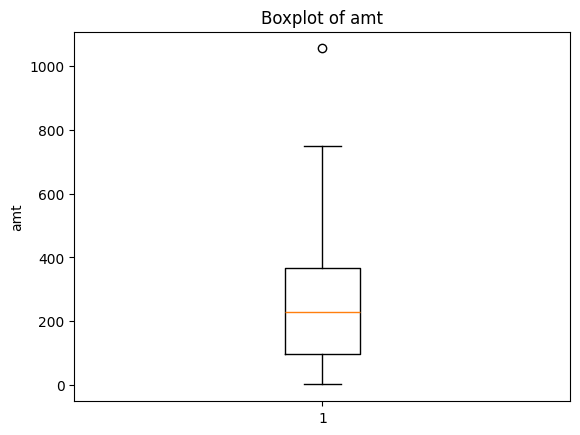

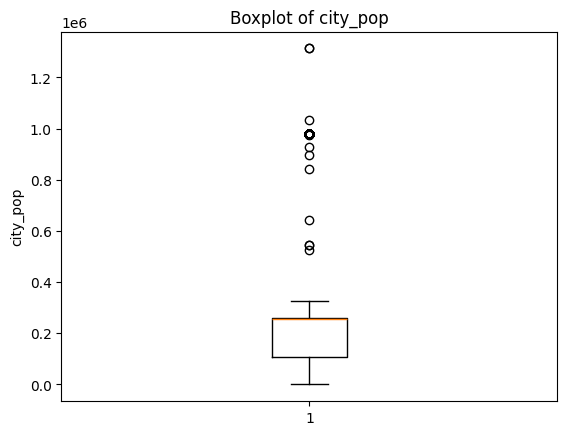

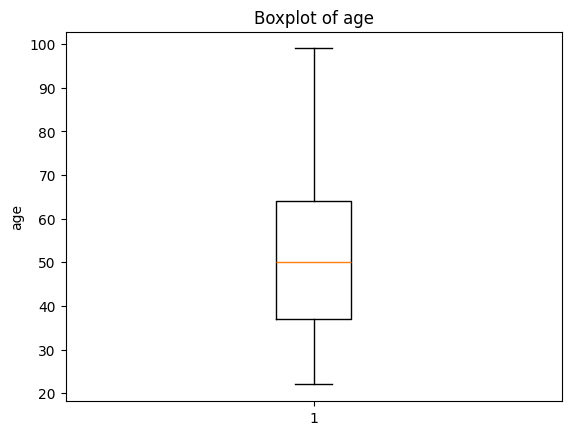


--- HANDLING OUTLIERS ---
Outliers handled successfully!

--- AFTER HANDLING ---
amt: 0 outliers remaining
city_pop: 0 outliers remaining
age: 0 outliers remaining


In [8]:
print("\n===== OUTLIER DETECTION & HANDLING =====")

import numpy as np
import matplotlib.pyplot as plt

# Columns where outlier handling is SAFE
outlier_cols = ['amt', 'city_pop', 'age']   # avoiding lat/long intentionally

# -------------------------------
# 1. Detect outliers using IQR
# -------------------------------
print("\n--- OUTLIER COUNTS ---")
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {outliers} outliers")

# -------------------------------
# 2. Visualize using boxplots
# -------------------------------
print("\n--- BOXPLOTS ---")
for col in outlier_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

# -------------------------------
# 3. Handle outliers (IQR method)
# -------------------------------
print("\n--- HANDLING OUTLIERS ---")

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Replace outliers with median (better than mean)
    median = df[col].median()
    df[col] = np.where((df[col] < lower) | (df[col] > upper), median, df[col])

print("Outliers handled successfully!")

# -------------------------------
# 4. Verify again
# -------------------------------
print("\n--- AFTER HANDLING ---")
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {outliers} outliers remaining") 

In [9]:
print("\n===== FEATURE SCALING =====")

from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

# Initialize scaler
scaler = StandardScaler()

# Apply scaling to features only
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame (for readability)
import pandas as pd
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())
print("\nShape:", X_scaled.shape) 


===== FEATURE SCALING =====
   merchant       amt      city       lat      long  city_pop       job  \
0 -0.470907 -0.834968  0.723829  0.421796 -0.160645 -2.460249 -0.704229   
1  0.168490 -0.088700  0.331098  0.076977 -0.046194 -2.409874  0.669920   
2 -0.044643 -0.907294 -0.297273  0.047759 -0.243673 -2.454715  1.847762   
3 -1.714180 -1.492515 -0.218727 -0.398131  0.077773 -2.450816  0.718997   
4 -1.394481 -1.498597 -0.493639  0.000000 -0.022475 -2.456199 -0.556999   

   merch_lat  merch_long  trans_hour  ...  state_NE   state_NM  state_NV  \
0   0.394797   -0.162523   -1.508431  ... -0.095346  -0.052058 -0.464513   
1   0.112065   -0.044452   -1.508431  ... -0.095346  -0.052058 -0.464513   
2   0.041801   -0.241678   -1.508431  ... -0.095346  -0.052058 -0.464513   
3  -0.372025    0.065833   -1.508431  ... -0.095346  19.209373 -0.464513   
4   0.140442   -0.030759   -1.508431  ... -0.095346  -0.052058 -0.464513   

   state_OH  state_OR  state_TX  state_UT   state_WA  state_WI 

In [16]:
df['is_fraud'] = df['is_fraud'].apply(lambda x: 1 if x >= 0.5 else 0) 
print(df['is_fraud'])  

0       0
1       0
2       0
3       0
4       0
       ..
1105    0
1106    0
1107    1
1108    0
1109    0
Name: is_fraud, Length: 1110, dtype: int64


In [10]:
print("\n===== END OF DATA PREPROCESSING =====") 


===== END OF DATA PREPROCESSING =====


In [19]:
print("\n===== START OF PHASE-2 =====") 


===== START OF PHASE-2 =====


In [20]:
print("\n===== LOGISTIC REGRESSION (BALANCED) =====")

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model with class balancing
model = LogisticRegression(max_iter=1000, class_weight='balanced')

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("\n===== RESULTS =====")

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred)) 


===== LOGISTIC REGRESSION (BALANCED) =====

===== RESULTS =====
Accuracy: 0.5135135135135135

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.49      0.61       169
           1       0.26      0.58      0.36        53

    accuracy                           0.51       222
   macro avg       0.53      0.54      0.49       222
weighted avg       0.67      0.51      0.55       222


Confusion Matrix:

[[83 86]
 [22 31]]



===== KNN CLASSIFIER =====

===== KNN RESULTS =====
Accuracy: 0.7117117117117117

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.91      0.83       169
           1       0.21      0.08      0.11        53

    accuracy                           0.71       222
   macro avg       0.48      0.49      0.47       222
weighted avg       0.63      0.71      0.66       222


Confusion Matrix:
 [[154  15]
 [ 49   4]]


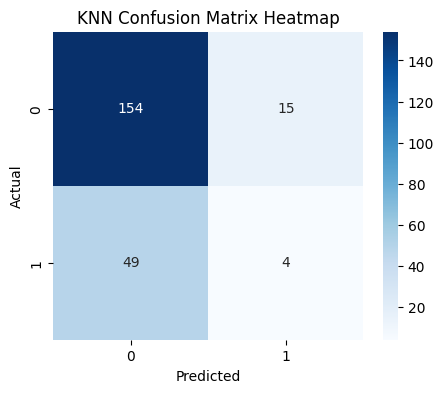

In [24]:
print("\n===== KNN CLASSIFIER =====")

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize KNN with improvement
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')

# Train
knn.fit(X_train, y_train)

# Predict
y_pred_knn = knn.predict(X_test)

# Evaluation
print("\n===== KNN RESULTS =====")

print("Accuracy:", accuracy_score(y_test, y_pred_knn))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)

print("\nConfusion Matrix:\n", cm)

# Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix Heatmap")

plt.show() 

In [6]:
print("===== END OF PHASE-2 =====") 

===== END OF PHASE-2 =====
